In [1]:
import sys, json, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.25})
BAD, GOOD, NEUTRAL, ACCENT = "#c0392b", "#1e8449", "#7f8c8d", "#2c6fbb"
RES = "../data/results/"


# 02 - Validation on real randomized experiments

| Dataset | What it is |
|---|---|
| **Criteo Uplift v2.1** | 13.98M users in a real ad experiment (85% treated / 15% control) |
| **Hillstrom** | 64,000 customers in a real email test |

Metrics, SRM check, z-test and CUPED are implemented in **SQL** (DuckDB, see `sql/`) and cross-checked against Python.

In [2]:
r = json.load(open(RES + "real_data.json"))
c = r["criteo"]
print(f'rows {c["rows"]:,}  treatment share {c["treatment_share"]:.6f}  SRM chi2 vs documented 85%: {c["srm_chi2_vs_documented_85pct"]:.2e}  flag: {c["srm_flag"]}')
print("SQL z =", round(c["conversion"]["z_sql"], 4), "  Python z =", round(c["conversion"]["z_python"], 4), "  match:", c["conversion"]["sql_python_match"])
print("Real A/A (control split at random, 1,000 runs):", {k: v["false_positive_rate"] for k, v in c["real_aa"].items()})

rows 13,979,592  treatment share 0.850000  SRM chi2 vs documented 85%: 1.82e-06  flag: False
SQL z = 28.5165   Python z = 28.5165   match: True
Real A/A (control split at random, 1,000 runs): {'conversion': 0.051, 'visit': 0.048}


In [3]:
for m in ("visit", "conversion"):
    x = c[m]
    print(f'{m}: control {x["control_rate"]:.4%} -> treatment {x["treatment_rate"]:.4%}  ({x["rel_lift"]:+.1%} relative, 95% CI {x["ci"][0]:.4%} to {x["ci"][1]:.4%})')

visit: control 3.8201% -> treatment 4.8543%  (+27.1% relative, 95% CI 1.0056% to 1.0629%)
conversion: control 0.1938% -> treatment 0.3089%  (+59.4% relative, 95% CI 0.1085% to 0.1219%)


## A real-data surprise: the arms are not perfectly balanced
In a randomized experiment, pre-treatment features should have the same mean in both arms. With 14M users the standardized difference should be around 0.0005.

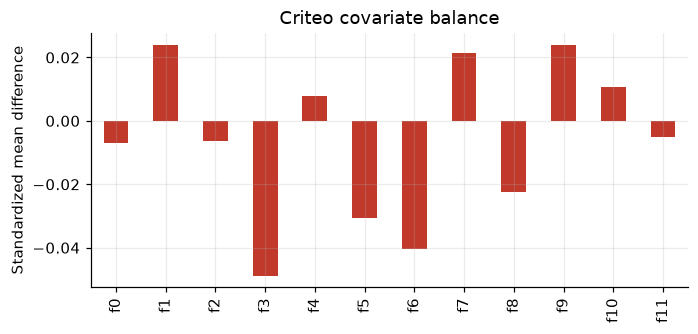

max |SMD| = 0.049
visit effect: raw +0.0103  vs  adjusted for the 12 features +0.0070  (-27 standard errors apart)


In [4]:
smd = pd.Series(c["smd"])
ax = smd.plot.bar(color=BAD, figsize=(7, 3)); ax.set(ylabel="Standardized mean difference", title="Criteo covariate balance"); plt.show()
print(f'max |SMD| = {c["max_abs_smd"]:.3f}')
a = c["ancova"]["visit"]
print(f'visit effect: raw {a["effect_raw"]:+.4f}  vs  adjusted for the 12 features {a["effect_ancova"]:+.4f}  ({a["effect_shift_in_se_units"]:+.0f} standard errors apart)')

**Reading this:** covariate adjustment moves the estimate far more than sampling noise could, which means the treated and control groups differ in ways the features capture. I cannot tell from the data whether that comes from the public release or from how the features were built, so both estimates are reported. The health checker's **Balance** check flags this class of problem.

## CUPED / covariate adjustment on real data

In [5]:
a = c["ancova"]
print(pd.DataFrame(a).T[["se_reduction", "sample_needed_ratio"]].rename(columns={"se_reduction": "SE reduction", "sample_needed_ratio": "sample needed vs unadjusted"}))
h = r["hillstrom"]
print(f'\nHillstrom: corr(pre-period spend, spend) = {h["corr_history_spend"]:.3f}, variance removed by CUPED = {h["variance_reduction_python"]:.4%}')

            SE reduction  sample needed vs unadjusted
visit           0.136901                     0.744940
conversion      0.061222                     0.881304

Hillstrom: corr(pre-period spend, spend) = 0.020, variance removed by CUPED = 0.0381%


**So what:** CUPED's gain scales with the squared correlation between the covariate and the metric. On Criteo the features predict visits well enough to save a meaningful share of users; on Hillstrom, past spend barely predicts future spend (correlation about 0.02), so CUPED does almost nothing. A variance-reduction method is only as good as its covariate.